In [1]:
!pip install kaggle

In [2]:
!pip install kagglehub

In [3]:
import kagglehub
import pandas as pd 

# Download latest version
path = kagglehub.dataset_download("nitaisatapathy/welfake-dataset")

print("Path to dataset files:", path)

df = pd.read_csv(f"{path}/WELFake_Dataset.csv")
df.head()

Path to dataset files: /home/hatem/.cache/kagglehub/datasets/nitaisatapathy/welfake-dataset/versions/1


,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [4]:
welfake = df
welfake = welfake.dropna()
welfake.isnull().sum()

Unnamed: 0    0
title         0
text          0
label         0
dtype: int64

In [5]:
welfake['content'] = "Title: " + welfake['title'].fillna("") + " Body: " + welfake['text']
welfake = welfake[['content', 'label']].rename(columns={'content': 'text'})
welfake.sample(7)

,text,label
33343,"Title: Hillary Clinton, North Carolina, Zika: ...",0
52949,Title: Why Did They Vote For Trump? Body: By A...,1
36919,Title: Trump spoke by phone to Egypt's Sisi to...,0
60803,Title: Comment on India Moves to Severely Rest...,1
34509,Title: Iraq sends delegation to Iran 'to coord...,0
30819,Title: IS HILLARY ABOUT TO BE “BERNED?”…Obama ...,1
16999,Title: Congresswoman BLASTS GOP For Confirmin...,1


### Liar Dataset

In [6]:
from datasets import load_dataset

# Test if it loads
liar_raw = load_dataset("chengxuphd/liar2")
print(liar_raw)
print(liar_raw["train"].column_names)

DatasetDict({
    train: Dataset({
        features: ['id', 'label', 'statement', 'date', 'subject', 'speaker', 'speaker_description', 'state_info', 'true_counts', 'mostly_true_counts', 'half_true_counts', 'mostly_false_counts', 'false_counts', 'pants_on_fire_counts', 'context', 'justification'],
        num_rows: 18369
    })
    validation: Dataset({
        features: ['id', 'label', 'statement', 'date', 'subject', 'speaker', 'speaker_description', 'state_info', 'true_counts', 'mostly_true_counts', 'half_true_counts', 'mostly_false_counts', 'false_counts', 'pants_on_fire_counts', 'context', 'justification'],
        num_rows: 2297
    })
    test: Dataset({
        features: ['id', 'label', 'statement', 'date', 'subject', 'speaker', 'speaker_description', 'state_info', 'true_counts', 'mostly_true_counts', 'half_true_counts', 'mostly_false_counts', 'false_counts', 'pants_on_fire_counts', 'context', 'justification'],
        num_rows: 2296
    })
})
['id', 'label', 'statement', 'date',

In [7]:
# Just run this first so we can see what labels exist
import pandas as pd
from collections import Counter

labels = liar_raw["train"]["label"]
print(Counter(labels))
print("\nSample:", labels[:10])

Counter({1: 5284, 3: 2967, 2: 2882, 4: 2743, 0: 2425, 5: 2068})

Sample: [5, 1, 0, 4, 2, 0, 2, 3, 1, 1]


In [8]:
# Run this to see a few examples with their labels
for i in range(6):
    sample = liar_raw["train"][i]
    print(f"Label: {sample['label']} | Statement: {sample['statement'][:80]}")
    print(f"Justification: {sample['justification'][:80]}")
    print("-" * 50)

Label: 5 | Statement: 90 percent of Americans "support universal background checks" for gun purchases.
Justification: "Universal" is the term for background checks to be done on every gun sale. We f
--------------------------------------------------
Label: 1 | Statement: Last year was one of the deadliest years ever for law enforcement officers.
Justification: Sen. Thom Tillis, a North Carolina Republican, said a new pro-police law is need
--------------------------------------------------
Label: 0 | Statement: Bernie Sanders's plan is "to raise your taxes to 90 percent.
Justification: Christie said that Sanders’s plan is "to raise your taxes to 90 percent." Sander
--------------------------------------------------
Label: 4 | Statement: Voter ID is supported by an overwhelming majority of NYers, from all across the 
Justification: Zeldin claimed voter identification requirements are supported by an overwhelmin
--------------------------------------------------
Label: 2 | Statement: Say

In [9]:
# LIAR2 mapping to match WELFake convention
liar_label_map = {
    0: 1,     # pants-fire  → Fake
    1: 1,     # false       → Fake
    2: 1,     # barely-true → Fake
    3: None,  # half-true   → DROP
    4: 0,     # mostly-true → Real
    5: 0,     # true        → Real
}

In [10]:
from sklearn.utils import resample 



def collapse_liar(example):
    mapping = {
        "true": 0,
        "mostly-true": 0,
        "half-true": None,      # drop these
        "barely-true": 1,
        "false": 1,
        "pants-fire": 1
    }
    example["binary_label"] = mapping[example["label"]]
    return example




In [11]:
print(welfake['text'].iloc[16])

Title: U.N. seeks humanitarian pause in Sanaa where streets "battlegrounds" Body: GENEVA (Reuters) - The United Nations called on Monday for a humanitarian pause in the Yemeni capital of Sanaa on Tuesday to allow civilians to leave their homes, aid workers to reach them, and the wounded to get medical care. Jamie McGoldrick, U.N. humanitarian coordinator in Yemen, said in a statement that the streets of Sanaa had become  battlegrounds  and that aid workers  remain in lockdown .  Thus, I call on all parties to the conflict to urgently enable a humanitarian pause on Tuesday 5 December, between 10:00 a.m. and 16:00 p.m. to allow civilians to leave their homes and seek assistance and protection and to facilitate the movement of aid workers to ensure the continuity of life-saving programs,  he said.  McGoldrick warned the warring parties that any deliberate attacks against civilians, and against civilian and medical infrastructure, are  clear violations of international humanitarian law and

In [14]:
import pandas as pd
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.utils import resample

# ── 1. WELFAKE ──────────────────────────────────────────
# Assumes you already ran:
# path = kagglehub.dataset_download("nitaisatapathy/welfake-dataset")

welfake_path = f"{path}/WELFake_Dataset.csv"
welfake_raw = pd.read_csv(welfake_path)

welfake_df = welfake_raw.copy()
welfake_df = welfake_df.dropna(subset=["text", "label"])
welfake_df["title"] = welfake_df["title"].fillna("")
welfake_df["text"] = welfake_df["text"].fillna("")
welfake_df["text"] = (
    "Title: " + welfake_df["title"].astype(str) +
    " [SEP] Body: " + welfake_df["text"].astype(str)
)
welfake_df = welfake_df[["text", "label"]].copy()
welfake_df["text"] = welfake_df["text"].astype(str)
welfake_df["label"] = welfake_df["label"].astype(int)
welfake_df["source"] = "welfake"

print(f"WELFake: {len(welfake_df)} examples")
print(welfake_df["label"].value_counts())

# ── 2. LIAR2 ────────────────────────────────────────────
liar_raw = load_dataset("chengxuphd/liar2")

liar_label_map = {
    0: 1,     # pants-fire  -> Fake
    1: 1,     # false       -> Fake
    2: 1,     # barely-true -> Fake
    3: None,  # half-true   -> DROP
    4: 0,     # mostly-true -> Real
    5: 0,     # true        -> Real
}

def process_liar(example):
    new_label = liar_label_map[example["label"]]
    statement = str(example["statement"] or "")
    justification = str(example["justification"] or "")
    text = "Claim: " + statement + " [SEP] Context: " + justification
    return {"text": text, "label": new_label}

liar_train = liar_raw["train"].map(process_liar)
liar_val   = liar_raw["validation"].map(process_liar)
liar_test  = liar_raw["test"].map(process_liar)

liar_combined = pd.concat([
    pd.DataFrame({"text": liar_train["text"], "label": liar_train["label"]}),
    pd.DataFrame({"text": liar_val["text"],   "label": liar_val["label"]}),
    pd.DataFrame({"text": liar_test["text"],  "label": liar_test["label"]}),
], ignore_index=True)

liar_df = liar_combined.dropna(subset=["text", "label"]).copy()
liar_df["text"] = liar_df["text"].astype(str)
liar_df["label"] = liar_df["label"].astype(int)
liar_df["source"] = "liar"

print(f"\nLIAR2 after processing: {len(liar_df)} examples")
print(liar_df["label"].value_counts())

# ── 3. MERGE ONLY WELFAKE + LIAR ────────────────────────
combined_df = pd.concat(
    [welfake_df, liar_df],
    ignore_index=True
)

# Basic cleanup
combined_df["text"] = (
    combined_df["text"]
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

combined_df = combined_df.dropna(subset=["text", "label"]).copy()
combined_df = combined_df[combined_df["text"].str.len() > 20].copy()
combined_df["label"] = combined_df["label"].astype(int)

# Remove exact duplicates
combined_df = combined_df.drop_duplicates(subset=["text"]).reset_index(drop=True)

print(f"\n{'='*50}")
print("COMBINED CLEAN DATASET")
print(f"Total examples : {len(combined_df)}")
print(f"\nBy source:\n{combined_df['source'].value_counts()}")
print(f"\nBy label:\n{combined_df['label'].value_counts()}")
print(f"{'='*50}")

# ── 4. SPLIT BEFORE OVERSAMPLING ────────────────────────
train_df, test_df = train_test_split(
    combined_df,
    test_size=0.2,
    stratify=combined_df["label"],
    random_state=42
)

print("\nTrain label counts:")
print(train_df["label"].value_counts())

print("\nTest label counts:")
print(test_df["label"].value_counts())

print("\nTrain source counts:")
print(train_df["source"].value_counts())

print("\nTest source counts:")
print(test_df["source"].value_counts())

# ── 5. OVERSAMPLE TRAIN ONLY ────────────────────────────
train_major = train_df[train_df["label"] == train_df["label"].mode()[0]]
train_minor = train_df[train_df["label"] != train_df["label"].mode()[0]]

if len(train_major) > len(train_minor):
    train_minor_up = resample(
        train_minor,
        replace=True,
        n_samples=len(train_major),
        random_state=42
    )
    train_df_balanced = pd.concat([train_major, train_minor_up], ignore_index=True)
else:
    train_major_up = resample(
        train_major,
        replace=True,
        n_samples=len(train_minor),
        random_state=42
    )
    train_df_balanced = pd.concat([train_major_up, train_minor], ignore_index=True)

train_df_balanced = train_df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\n{'='*50}")
print("FINAL TRAIN / TEST SETUP")
print(f"Balanced train size : {len(train_df_balanced)}")
print(f"Test size           : {len(test_df)}")
print(f"\nBalanced train labels:\n{train_df_balanced['label'].value_counts()}")
print(f"\nTest labels:\n{test_df['label'].value_counts()}")
print(f"{'='*50}")

# ── 6. QUICK SANITY CHECK ───────────────────────────────
print("\nSample from balanced train set:")
for i in [0, 1, 2]:
    row = train_df_balanced.iloc[i]
    print(f"\nSource: {row['source']}")
    print(f"Label: {'Real' if row['label'] == 0 else 'Fake'}")
    print(f"Text: {row['text'][:120]}...")


WELFake: 72095 examples
label
1    37067
0    35028
Name: count, dtype: int64

LIAR2 after processing: 19253 examples
label
1    13239
0     6014
Name: count, dtype: int64

COMBINED CLEAN DATASET
Total examples : 82865

By source:
source
welfake    63633
liar       19232
Name: count, dtype: int64

By label:
label
1    42073
0    40792
Name: count, dtype: int64

Train label counts:
label
1    33658
0    32634
Name: count, dtype: int64

Test label counts:
label
1    8415
0    8158
Name: count, dtype: int64

Train source counts:
source
welfake    50903
liar       15389
Name: count, dtype: int64

Test source counts:
source
welfake    12730
liar        3843
Name: count, dtype: int64

FINAL TRAIN / TEST SETUP
Balanced train size : 67316
Test size           : 16573

Balanced train labels:
label
1    33658
0    33658
Name: count, dtype: int64

Test labels:
label
1    8415
0    8158
Name: count, dtype: int64

Sample from balanced train set:

Source: liar
Label: Fake
Text: Claim: Video of a Q&A 

In [15]:
from datasets import Dataset
from transformers import AutoTokenizer

model_name = "roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

train_dataset = Dataset.from_pandas(
    train_df_balanced[["text", "label", "source"]].reset_index(drop=True)
)
test_dataset = Dataset.from_pandas(
    test_df[["text", "label", "source"]].reset_index(drop=True)
)

def tokenize_function(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=256
    )

train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

train_dataset = train_dataset.rename_column("label", "labels")
test_dataset = test_dataset.rename_column("label", "labels")

train_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

test_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

print(train_dataset)
print(test_dataset)
print(train_dataset[0])


Map:   0%|          | 0/67316 [00:00<?, ? examples/s]

Map:   0%|          | 0/16573 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'labels', 'source', 'input_ids', 'attention_mask'],
    num_rows: 67316
})
Dataset({
    features: ['text', 'labels', 'source', 'input_ids', 'attention_mask'],
    num_rows: 16573
})
{'labels': tensor(1), 'input_ids': tensor([    0, 45699,    35,  5338,     9,    10,  1209,   947,   250,  1263,
           31,  1645,    18, 10096, 13815,    14, 28033,  9738,  5290,    32,
          145,   341,    22,   560,  1888,     5,  1050,  1956,     4,   646,
         3388,   510,   742, 43885,    35,    83, 37177, 41650,   569,  3649,
           14, 10096,    17,    27,    29,  1948,     7,    10,   864,    59,
        28033,  9738,  5290,  1474,    51,    32,   145,   341,     7,  1888,
            5,  1050,  1956,     4, 16092,  9738,  5290,    32,    45,   588,
            6,     8,  4211,   224,    22,  3056,    12,  5087, 31935,  2166,
            8,  4747,  5588,   113, 41078,     5,  1697,    13,   106,     4,
          345,    32,   484,  2188, 10096,   42

In [16]:
import numpy as np
import torch
from scipy.special import softmax
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer

model_name = "roberta-base"
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    probs = softmax(logits, axis=1)[:, 1]

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary", zero_division=0
    )
    acc = accuracy_score(labels, preds)

    try:
        auc = roc_auc_score(labels, probs)
    except:
        auc = 0.0

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": auc,
    }

training_args = TrainingArguments(
    output_dir="./roberta_fake_news",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=100,
    learning_rate=2e-5,
    per_device_train_batch_size=12,
    per_device_eval_batch_size=12,
    gradient_accumulation_steps=2,
    num_train_epochs=3,
    weight_decay=0.01,
    warmup_ratio=0.1,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    fp16=torch.cuda.is_available(),
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)



Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.bias               | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [17]:
trainer.train()


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.153156,0.070573,0.978399,0.980212,0.977184,0.978696,0.998095
2,0.092890,0.087447,0.979062,0.972255,0.986928,0.979536,0.998412
3,0.032234,0.116072,0.980028,0.980504,0.980154,0.980329,0.998517


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=8415, training_loss=0.13936444634988912, metrics={'train_runtime': 3178.0627, 'train_samples_per_second': 63.544, 'train_steps_per_second': 2.648, 'total_flos': 2.656737570392064e+16, 'train_loss': 0.13936444634988912, 'epoch': 3.0})

In [21]:
import torch

id2label = {0: "REAL", 1: "FAKE"}

def predict_with_uncertainty(
    text,
    low_threshold=0.35,
    high_threshold=0.65,
    max_length=256
):
    model.eval()
    device = next(model.parameters()).device

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=max_length
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=1)[0]

    real_prob = probs[0].item()
    fake_prob = probs[1].item()
    pred_id = torch.argmax(probs).item()
    pred_label = id2label[pred_id]
    confidence = probs[pred_id].item()

    if fake_prob >= high_threshold:
        decision = "FAKE"
        note = "Model is confidently on the fake side."
    elif fake_prob <= low_threshold:
        decision = "REAL"
        note = "Model is confidently on the real side."
    else:
        decision = "UNCERTAIN"
        note = "Model is in the gray zone, so this should be reviewed manually."

    return {
        "decision": decision,
        "predicted_label": pred_label,
        "confidence": round(confidence, 4),
        "fake_probability": round(fake_prob, 4),
        "real_probability": round(real_prob, 4),
        "thresholds": {
            "low_threshold": low_threshold,
            "high_threshold": high_threshold
        },
        "note": note
    }


In [22]:
examples = [
    {
        "name": "Obvious fake",
        "text": """
        BREAKING: Scientists confirm that drinking hot lemon water for three days
        completely eliminates all cancer cells. Major hospitals are refusing to
        reveal this cheap cure because drug companies would lose billions.
        """
    },
    {
        "name": "Normal real-style news",
        "text": """
        The city council approved a new transportation budget on Tuesday after a
        two-hour debate. Officials said the funding will be used to repair roads,
        improve bus stops, and expand traffic safety programs over the next year.
        """
    },
    {
        "name": "Tricky fake written calmly",
        "text": """
        A policy memo circulating online claims that several public schools will begin
        replacing human teachers with AI systems for all core subjects by next semester.
        The document has been widely shared, but no district has published an official
        implementation plan or board approval.
        """
    },
    {
        "name": "True but sensational",
        "text": """
        Health officials reported a sharp increase in measles cases across multiple
        states this month, prompting emergency vaccination campaigns and temporary
        quarantine guidance in several counties.
        """
    },
    {
        "name": "Half-true / misleading framing",
        "text": """
        A viral post says a new study proved electric vehicles are worse for the
        environment than gasoline cars. Researchers did note that battery production
        has a high environmental cost, but the paper did not conclude that EVs are
        worse overall across their full lifetime.
        """
    },
    {
        "name": "Political claim with missing evidence",
        "text": """
        Commentators online say the governor secretly redirected disaster relief money
        to a private campaign consulting firm. The allegation is based on screenshots,
        but no audited public record or court filing has confirmed the transfer.
        """
    },
    {
        "name": "Real claim-style statement",
        "text": """
        The central bank announced that interest rates would remain unchanged this
        quarter, citing slower inflation and mixed labor market data.
        """
    },
    {
        "name": "Conspiracy tone",
        "text": """
        Several insiders have exposed a hidden international plan to use weather
        satellites to trigger floods in regions that oppose global trade rules.
        Mainstream media outlets are ignoring the evidence.
        """
    }
]


In [23]:
for ex in examples:
    print("\n" + "="*60)
    print(ex["name"])
    print(predict_with_uncertainty(ex["text"]))



Obvious fake
{'decision': 'FAKE', 'predicted_label': 'FAKE', 'confidence': 1.0, 'fake_probability': 1.0, 'real_probability': 0.0, 'thresholds': {'low_threshold': 0.35, 'high_threshold': 0.65}, 'note': 'Model is confidently on the fake side.'}

Normal real-style news
{'decision': 'FAKE', 'predicted_label': 'FAKE', 'confidence': 0.8669, 'fake_probability': 0.8669, 'real_probability': 0.1331, 'thresholds': {'low_threshold': 0.35, 'high_threshold': 0.65}, 'note': 'Model is confidently on the fake side.'}

Tricky fake written calmly
{'decision': 'FAKE', 'predicted_label': 'FAKE', 'confidence': 1.0, 'fake_probability': 1.0, 'real_probability': 0.0, 'thresholds': {'low_threshold': 0.35, 'high_threshold': 0.65}, 'note': 'Model is confidently on the fake side.'}

True but sensational
{'decision': 'FAKE', 'predicted_label': 'FAKE', 'confidence': 0.9997, 'fake_probability': 0.9997, 'real_probability': 0.0003, 'thresholds': {'low_threshold': 0.35, 'high_threshold': 0.65}, 'note': 'Model is confid

In [24]:
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


Classification Report:

              precision    recall  f1-score   support

        REAL     0.9795    0.9799    0.9797      8158
        FAKE     0.9805    0.9802    0.9803      8415

    accuracy                         0.9800     16573
   macro avg     0.9800    0.9800    0.9800     16573
weighted avg     0.9800    0.9800    0.9800     16573

Confusion Matrix:

[[7994  164]
 [ 167 8248]]


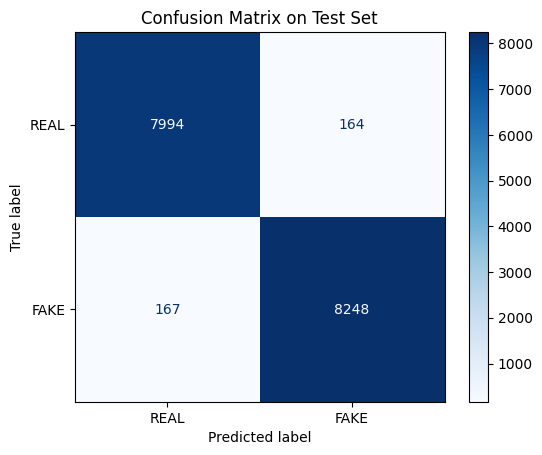


Accuracy on test_df: 0.98

Accuracy by source:
source
liar       0.9235
welfake    0.9971
Name: correct, dtype: float64

Number of wrong predictions: 331

Sample wrong predictions:

Source: liar
True Label: REAL
Predicted : FAKE
Fake Prob : 1.0
Text      : Claim: Says Joe Biden has said 150 million Americans died from guns and another 120 million from COVID-19 [SEP] Context: A Facebook post said Biden said 120 million Americans died from COVID-19 and that 150 million Americans died from gun violence since 2007.  Both of those numbers are drastically . Biden meant to say "thousands" in both cases, not "millions." The post is correct that Biden did make these claims, but after misstating the COVID stat he immediately corrected himself, a detail the 

Source: liar
True Label: REAL
Predicted : FAKE
Fake Prob : 0.9984
Text      : Claim: Says Donald "Trump supported impeachment of President (George W.) Bush. [SEP] Context: An ad by the super PAC Our Principles said Trump supported the impea

In [25]:
# 1. Get predictions on the Hugging Face test dataset
pred_output = trainer.predict(test_dataset)

logits = pred_output.predictions
y_true = pred_output.label_ids
y_pred = np.argmax(logits, axis=1)
y_prob = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]

# 2. Main metrics report
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=["REAL", "FAKE"], digits=4))

# 3. Confusion matrix
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n")
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["REAL", "FAKE"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix on Test Set")
plt.show()

# 4. Attach predictions back to test_df for inspection
test_results_df = test_df.reset_index(drop=True).copy()
test_results_df["pred_label"] = y_pred
test_results_df["fake_probability"] = y_prob
test_results_df["correct"] = (test_results_df["label"] == test_results_df["pred_label"])

print("\nAccuracy on test_df:", (test_results_df["correct"].mean()).round(4))

# 5. Source-wise performance
print("\nAccuracy by source:")
print(test_results_df.groupby("source")["correct"].mean().round(4))

# 6. Show wrong predictions
wrong_df = test_results_df[test_results_df["correct"] == False].copy()

print("\nNumber of wrong predictions:", len(wrong_df))

display_cols = ["source", "label", "pred_label", "fake_probability", "text"]
wrong_df = wrong_df[display_cols]

print("\nSample wrong predictions:")
for i, row in wrong_df.head(10).iterrows():
    print("\n" + "="*80)
    print("Source:", row["source"])
    print("True Label:", "REAL" if row["label"] == 0 else "FAKE")
    print("Predicted :", "REAL" if row["pred_label"] == 0 else "FAKE")
    print("Fake Prob :", round(row["fake_probability"], 4))
    print("Text      :", row["text"][:500])


In [26]:
examples = [
    {
        "name": "Obvious fake miracle cure",
        "text": """
        BREAKING: Doctors have confirmed that drinking a spoonful of heated olive oil
        every morning completely destroys cancer cells within 48 hours. Hospitals are
        hiding the treatment because it would bankrupt the pharmaceutical industry.
        """
    },
    {
        "name": "Normal local government news",
        "text": """
        The city council approved a revised housing budget after a public meeting on
        Monday night. Officials said the plan includes funding for road repairs,
        rental assistance, and safety inspections over the next fiscal year.
        """
    },
    {
        "name": "Real economic news style",
        "text": """
        The labor department reported that unemployment claims fell slightly last week,
        while wage growth remained steady. Economists said the figures suggest the job
        market is cooling gradually rather than weakening sharply.
        """
    },
    {
        "name": "Tricky fake written formally",
        "text": """
        A leaked internal report shows that several universities have quietly approved
        a policy to replace most lecturers with AI systems beginning next semester.
        Administrators have allegedly agreed not to announce the transition until
        student tuition payments are finalized.
        """
    },
    {
        "name": "True but alarming public health news",
        "text": """
        State health officials confirmed a rise in measles cases across several
        counties, prompting temporary quarantine recommendations for unvaccinated
        residents and expanded vaccine clinics this week.
        """
    },
    {
        "name": "Misleading climate claim",
        "text": """
        Viral posts claim that a new scientific paper proves climate change stopped
        ten years ago. The study actually examined short-term regional variability and
        did not conclude that long-term global warming had ended.
        """
    },
    {
        "name": "Political rumor with no confirmation",
        "text": """
        Social media users say the governor secretly diverted emergency disaster funds
        to a consulting firm tied to campaign donors. No state audit, court filing,
        or official financial record has verified the allegation.
        """
    },
    {
        "name": "True court reporting",
        "text": """
        A federal appeals court ruled on Friday that the agency exceeded its authority
        when it issued the regulation without public notice and comment, sending the
        matter back for further review.
        """
    },
    {
        "name": "Classic conspiracy framing",
        "text": """
        Several independent researchers have exposed a hidden international program
        using satellites to control weather patterns and punish countries that reject
        new trade agreements, but major broadcasters refuse to cover the evidence.
        """
    },
    {
        "name": "Ambiguous claim-check style",
        "text": """
        A viral post says the mayor doubled property taxes in a single year. Budget
        documents show overall property tax revenue increased, but the change varied by
        district and many homeowners did not see their bill double.
        """
    },
    {
        "name": "Real science reporting",
        "text": """
        Researchers at a university medical center said an early-stage trial found that
        the new treatment improved symptom control in some patients, though they warned
        that larger studies are still needed before broad conclusions can be drawn.
        """
    },
    {
        "name": "Fake security panic",
        "text": """
        Intelligence officials have privately warned that smartphones made after 2022
        contain hidden chips designed to broadcast user conversations directly to
        foreign governments every night at midnight.
        """
    },
    {
        "name": "Calm fake policy claim",
        "text": """
        Education officials have finalized a nationwide rule requiring all schools to
        replace printed exams with biometric surveillance testing by the end of the
        year, according to a memo shared online but not published by any ministry.
        """
    },
    {
        "name": "Real disaster reporting",
        "text": """
        Emergency crews said floodwaters damaged dozens of homes after heavy rainfall
        overnight, while utility teams worked to restore electricity to several rural
        communities by Saturday afternoon.
        """
    },
    {
        "name": "Half-true misleading framing",
        "text": """
        Online commentators say electric vehicles are more polluting than gasoline cars
        because battery production creates significant emissions. Environmental analysts
        note that battery manufacturing is intensive, but lifetime emissions are often
        lower depending on the electricity source.
        """
    }
]


In [27]:
for ex in examples:
    print("\n" + "=" * 80)
    print("Example:", ex["name"])
    print("Text:", ex["text"].strip()[:300], "...")
    print("Prediction:", predict_with_uncertainty(ex["text"]))



Example: Obvious fake miracle cure
Text: BREAKING: Doctors have confirmed that drinking a spoonful of heated olive oil
        every morning completely destroys cancer cells within 48 hours. Hospitals are
        hiding the treatment because it would bankrupt the pharmaceutical industry. ...
Prediction: {'decision': 'FAKE', 'predicted_label': 'FAKE', 'confidence': 1.0, 'fake_probability': 1.0, 'real_probability': 0.0, 'thresholds': {'low_threshold': 0.35, 'high_threshold': 0.65}, 'note': 'Model is confidently on the fake side.'}

Example: Normal local government news
Text: The city council approved a revised housing budget after a public meeting on
        Monday night. Officials said the plan includes funding for road repairs,
        rental assistance, and safety inspections over the next fiscal year. ...
Prediction: {'decision': 'UNCERTAIN', 'predicted_label': 'FAKE', 'confidence': 0.5747, 'fake_probability': 0.5747, 'real_probability': 0.4253, 'thresholds': {'low_threshold': 0.35,

In [34]:
import gradio as gr
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

MODEL_PATH = "fake_news_bert_model"

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

def format_result_card(decision, confidence, fake_prob, real_prob, explanation):
    if decision == "FAKE":
        color = "#b91c1c"
        bg = "#fee2e2"
        badge = "High misinformation risk"
    elif decision == "REAL":
        color = "#166534"
        bg = "#dcfce7"
        badge = "Low misinformation risk"
    else:
        color = "#92400e"
        bg = "#fef3c7"
        badge = "Needs manual review"

    return f"""
    <div style="
        border-radius: 18px;
        padding: 18px;
        background: {bg};
        border: 1px solid {color};
        font-family: Arial, sans-serif;
        box-shadow: 0 6px 20px rgba(0,0,0,0.08);
    ">
        <div style="font-size: 26px; font-weight: 700; color: {color};">
            {decision}
        </div>
        <div style="margin-top: 6px; font-size: 15px; color: #222;">
            {badge}
        </div>
        <hr style="margin: 12px 0; border: none; border-top: 1px solid rgba(0,0,0,0.12);">
        <div style="font-size: 14px; color: #222; line-height: 1.7;">
            <b>Confidence:</b> {confidence:.2%}<br>
            <b>Fake Probability:</b> {fake_prob:.2%}<br>
            <b>Real Probability:</b> {real_prob:.2%}
        </div>
        <div style="margin-top: 12px; font-size: 14px; color: #333; line-height: 1.6;">
            {explanation}
        </div>
    </div>
    """

def predict_news(headline, body, low_threshold=0.25, high_threshold=0.75, max_length=256):
    headline = (headline or "").strip()
    body = (body or "").strip()

    if not headline and not body:
        empty_html = """
        <div style="padding:16px;border-radius:14px;background:#f3f4f6;border:1px solid #d1d5db;font-family:Arial,sans-serif;">
            Please enter a headline, body, or both.
        </div>
        """
        return empty_html, 0.0, 0.0, 0.0

    text = f"Title: {headline} [SEP] Body: {body}" if body else headline

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=max_length
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=1)[0]

    real_prob = probs[0].item()
    fake_prob = probs[1].item()
    confidence = max(real_prob, fake_prob)

    if fake_prob >= high_threshold:
        decision = "FAKE"
        explanation = (
            "The model found strong misinformation-like text patterns. "
            "This is a research prediction based only on language cues, not verified evidence."
        )
    elif fake_prob <= low_threshold:
        decision = "REAL"
        explanation = (
            "The model found stronger legitimate-reporting patterns in the text. "
            "This is a research prediction based only on text, not full source verification."
        )
    else:
        decision = "UNCERTAIN"
        explanation = (
            "The model sees mixed signals in this text. "
            "That often happens with subtle, incomplete, or plausibly framed claims."
        )

    result_card = format_result_card(
        decision=decision,
        confidence=confidence,
        fake_prob=fake_prob,
        real_prob=real_prob,
        explanation=explanation
    )

    return result_card, fake_prob, real_prob, confidence

examples = [
    [
        "Scientists confirm olive oil destroys cancer cells in 48 hours",
        "Doctors have reportedly confirmed a miracle cure, but hospitals are hiding it because pharmaceutical companies would lose money."
    ],
    [
        "City council approves revised housing budget",
        "Officials said the funding will support road repairs, rental assistance, and safety inspections over the next fiscal year."
    ],
    [
        "New banking rule will limit how much cash people can withdraw each week without government review",
        "A widely shared post claims financial regulators are preparing a policy that would require banks to flag large cash withdrawals and temporarily delay repeated transactions above a weekly threshold. No official rule has been published, but screenshots said to come from an internal briefing are spreading quickly online."
    ],
    [
        "Leaked education plan would replace many first-year university lecturers with AI systems next semester",
        "Posts circulating online say several universities have already approved a cost-cutting plan to move large introductory courses to AI-based teaching platforms. The alleged document has not been released publicly, but users claim administrators are waiting until tuition deadlines pass before announcing the change."
    ],
    [
        "Viral post says electric vehicles are worse than gas cars",
        "Analysts note battery production has a cost, but lifetime emissions are often lower depending on the electricity source."
    ],
    [
        "Federal appeals court sends regulation back for review",
        "The court said the agency exceeded its authority by issuing the rule without proper notice and comment procedures."
    ],
]

with gr.Blocks(theme=gr.themes.Soft(), title="Misinformation Risk Classifier") as demo:
    gr.Markdown(
        """
        # RoBERTa Misinformation Risk Classifier
        Analyze a headline and supporting text to estimate whether it looks more like real reporting, misinformation, or an uncertain case.

        **Research demo only:** This tool uses text patterns, not live fact-checking or source verification.
        """
    )

    with gr.Row():
        with gr.Column(scale=2):
            headline = gr.Textbox(
                label="Headline / Claim",
                placeholder="Enter a headline or claim..."
            )
            body = gr.Textbox(
                label="Body / Context",
                placeholder="Enter article body, context, or supporting details...",
                lines=8
            )

            with gr.Row():
                submit_btn = gr.Button("Analyze", variant="primary")
                clear_btn = gr.Button("Clear")

        with gr.Column(scale=1):
            result_card = gr.HTML(label="Prediction")
            fake_score = gr.Slider(label="Fake Probability", minimum=0, maximum=1, step=0.001)
            real_score = gr.Slider(label="Real Probability", minimum=0, maximum=1, step=0.001)
            confidence = gr.Slider(label="Confidence", minimum=0, maximum=1, step=0.001)

    gr.Examples(
        examples=examples,
        inputs=[headline, body],
        label="Try These Sample Cases"
    )

    submit_btn.click(
        fn=predict_news,
        inputs=[headline, body],
        outputs=[result_card, fake_score, real_score, confidence]
    )

    clear_btn.click(
        fn=lambda: ("", 0.0, 0.0, 0.0),
        inputs=[],
        outputs=[result_card, fake_score, real_score, confidence]
    )

demo.launch()


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

/tmp/ipykernel_139426/2942206990.py:142: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(theme=gr.themes.Soft(), title="Misinformation Risk Classifier") as demo:


* Running on local URL:  http://127.0.0.1:7862
* To create a public link, set `share=True` in `launch()`.
